# **Initial Importing**

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

firstFilePath = "/Users/hudson/Desktop/road_project/facebook/data/facebook_pull_1.csv"
secondFilePath = "/Users/hudson/Desktop/road_project/facebook/data/facebook_pull_2.csv"
filePaths = [firstFilePath, secondFilePath]
dfList = [pd.read_csv(file) for file in filePaths]
dfMerged = pd.concat(dfList, ignore_index=True)
outputPath = "/Users/hudson/Desktop/road_project/facebook/data/facebook_merged.csv"
dfMerged.to_csv(outputPath)

firstFilePathURL = "/Users/hudson/Desktop/road_project/facebook/data/facebook_pull_1_URL.csv"
secondFilePathURL = "/Users/hudson/Desktop/road_project/facebook/data/facebook_pull_2_URL.csv"
filePathsURL = [firstFilePathURL, secondFilePathURL]
dfListURL = [pd.read_csv(file) for file in filePathsURL]
dfMergedURL = pd.concat(dfListURL, ignore_index=True)

---
# **Making Data Labled**  
### I self labeled the data so that it is an accurate labeling of whether it is a closure, reopening and so on. To do this I first self labeled 100 rows of data, and then fed the labeled data into a GPT model which then finished labeling the rest. I then took a random sample of 20 rows and validated they the rows were labeled correctly under my definitions. One thing that causes a little confusion comes from tweets that contain info on reopenings and closings. To solve this instead of giving it a label of one or the other, it actually recieves both! This will help when we are trying to find the length of the closure which will be extremely useful in later modeling.

In [90]:
labeledfilePath = "/Users/hudson/Desktop/road_project/facebook/data/facebook_merged_labeled.xlsx"
df = pd.read_excel(labeledfilePath)
print(df.columns)
# The new columns are the last few

Index(['Unnamed: 0', 'facebookId', 'facebookUrl', 'feedbackId', 'likes',
       'postId', 'timestamp', 'user/name', 'user/profilePic',
       'user/profileUrl', 'viewsCount', 'time', 'text', 'is_wb', 'is_eb',
       'is_closure', 'is_reopening', 'is_placing', 'is_lifting'],
      dtype='str')


---
# **Data Fixing** 
### The dates were in the wrong timezone, so I converted them to accurately match the facebook post. Now we can actuall merge this with weather.

In [91]:
df["timestamp"] = pd.to_datetime(df["timestamp"], unit = 's', utc = True)
df["timestamp"] = df["timestamp"].dt.tz_convert("US/Pacific")

df["URL"] = dfMergedURL["url"]


---
# **Starting EDA On Posts**

### First we will look into the distribution of the tweets with the different labels we just created. 

It seems that we have 463 closure posts within our data set. So the proportion of posts that are flagged as closure posts is 0.155


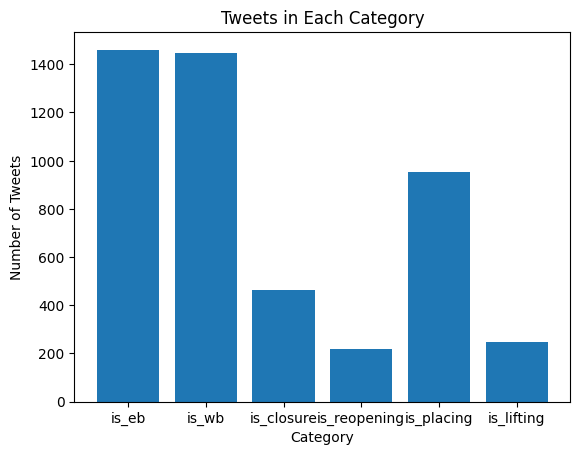

In [92]:
counts = df[["is_eb", "is_wb", "is_closure", "is_reopening", "is_placing", "is_lifting"]].sum()

plt.bar(counts.index, counts.values)
plt.title("Tweets in Each Category")
plt.xlabel("Category")
plt.ylabel("Number of Tweets")
closures = df[df["is_closure"] == 1]
closureCount = len(closures)
closureProportion = len(closures) / len(df)
print(f"It seems that we have {closureCount} closure posts within our data set. So the proportion of posts that are flagged as closure posts is {closureProportion:.3}")

closureOrReopening = df[(df["is_closure"] == 1) | (df["is_reopening"] == 1)]

## **Analysis**
### We can notice imbalances between different categories, especially is placing and is lifted. I really just labeled these for use in later projects or updates, so for now we can ignore them.

### There seems to be an imbalance also between closures and reopenings. After some quick exploration it is clear that this imbalance stems from posting the same closure more than once. On the other hand they usually only posted a reopening once.

### We have 463 posts being flagged as a closure. Lets now take a random sample of these and see if there labeled correctly as it COULD be overlabeling.

In [93]:
# pd.set_option('display.max_colwidth', None) # Set this back to 50 in the next cell so we dont keep getting HUGE rows.
# closures.sample(20)

## **Analysis** 
### I commented out the run because it takes up A LOT of room. After looking at 20 random samples I actually saw 0 overlabeling, which is great since I did not label every single row my self. I previously checked all rows, but seeing closures alone being correctly labeled was a big relief. A lot of the project is just based on this data set being good and viable. One problem I will guarenteed run into is figuring out how long the closures last, this is HIGHLY valuable in modeling, so I need to figure out a way to either extrapolate. The absolute easiest thing I could do for now is just use a mean of our sample data and hope it represents the population mean.

In [94]:
pd.set_option('display.max_colwidth', 50)


# **WRONG APPROACH**
## **Closure Length Wrangling**
### Big idea just dropped into the brain factory. While labeling our data we kept have special rows that contain both an opening and closure flag. This happens when a posts mentions a closure, but later updates with a reopening, which is exactly what we want. We can just take the difference between the update and the time here to calculate the duration. Then we can evaluate the distribion the closure times follow. I'm gonna export a excel file to wok on this and will push it back here when finished.

In [95]:
closureTimes = closures[closures["is_reopening"] == 1]
closureTimes['timestamp'] = closureTimes['timestamp'].dt.tz_localize(None)

In [96]:
closureTimes.to_excel("/Users/hudson/Desktop/road_project/facebook/data/closure_times.xlsx")

# **Better Approach** 
### Instead we will do this manually. This data is extremely crucial to an accurate model, so it will be worth the task.

In [98]:
closures['timestamp'] = closures['timestamp'].dt.tz_localize(None)
closureOrReopening['timestamp'] = closureOrReopening['timestamp'].dt.tz_localize(None)

closureOrReopening.to_excel("/Users/hudson/Desktop/road_project/facebook/data/manual_closure_or_reopening_times.xlsx")

# **Finished Labeling Times**
### Not every row set has easily excessible reopening times, BUT through manually going throiugh the closure tweets there were actually a lot of them where the data was availiable. The next step is to take the reopening time, and subtract off the closure time. This will give us the time closed. With this I am going to plot the closure times and see if we can find a similar distribution. Another idea may come in modeling. We can fit a regression model on every single closure, fitted to the ones we gaurenteed off tweets, and predict closure times for closures that do not have a given reopening time. We can take in weather features and time, hoping that we can get a decent accuracy.

---
# ***END OF THIS NOTEBOOK***